# KeroML BRIX Scenario Analysis (Least / Mean / Most Branching)

This notebook integrates theoretical BRIX limits (`keroml_theoretical_brix.dat`) into the KeroML cetane workflow.

What this notebook does:
1. Parses KeroML composition + CN data and BRIX min/max limits.
2. Builds BI features per class and overall from BRIX limits.
3. Trains a Ridge CN model with composition + BI features.
4. Produces three scenario predictions:
   - `cn_less_branch` (minimum BI for branched classes),
   - `cn_mean_branch` (mid BI),
   - `cn_more_branch` (maximum BI for branched classes).
5. Runs Monte Carlo BI perturbations within limits for uncertainty bands.

In [1]:
import re
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import KFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 220)
pd.set_option('display.width', 240)

In [2]:
def parse_tab_dat(file_path, non_numeric_cols=None):
    """Parse tab-separated .dat file after '# Data'."""
    if non_numeric_cols is None:
        non_numeric_cols = []

    with open(file_path, 'r') as f:
        lines = f.readlines()

    data_start = None
    for i, line in enumerate(lines):
        if line.startswith('# Data'):
            data_start = i + 2
            break
    if data_start is None:
        raise ValueError(f'Could not find # Data section in {file_path}.')

    headers = lines[data_start].strip().split('\t')
    rows = []
    for line in lines[data_start + 1:]:
        if line.strip() and not line.startswith('#'):
            parts = line.strip().split('\t')
            if len(parts) == len(headers):
                rows.append(parts)

    out = pd.DataFrame(rows, columns=headers)
    for c in out.columns:
        if c not in non_numeric_cols:
            out[c] = pd.to_numeric(out[c], errors='coerce')
    return out

keroml_candidates = [
    Path('../../model_training/keroml/training_data/keroml_dataset.dat'),
    Path('../model_training/keroml/training_data/keroml_dataset.dat'),
    Path('../keroml_dataset.dat'),
]
brix_candidates = [
    Path('../../model_training/keroml/training_data/keroml_theoretical_brix.dat'),
    Path('../model_training/keroml/training_data/keroml_theoretical_brix.dat'),
]

keroml_path = next((p for p in keroml_candidates if p.exists()), None)
brix_path = next((p for p in brix_candidates if p.exists()), None)
if keroml_path is None:
    raise FileNotFoundError('keroml_dataset.dat not found in known locations.')
if brix_path is None:
    raise FileNotFoundError('keroml_theoretical_brix.dat not found in known locations.')

df = parse_tab_dat(keroml_path, non_numeric_cols=['keroml_id', 'mixture_id', 'mixture_name', '2dgc_val_type'])
brix = parse_tab_dat(brix_path, non_numeric_cols=['theoretical_brix_id'])

print('KeroML path:', keroml_path.resolve())
print('BRIX path:', brix_path.resolve())
print('KeroML shape:', df.shape)
print('BRIX shape:', brix.shape)

KeroML path: /Users/aoxo/vscode/turingtrain/model_training/keroml/training_data/keroml_dataset.dat
BRIX path: /Users/aoxo/vscode/turingtrain/model_training/keroml/training_data/keroml_theoretical_brix.dat
KeroML shape: (1785, 214)
BRIX shape: (21, 37)


In [3]:
target_col = 'cetane_number_val'
feature_cols = [c for c in df.columns if c.startswith('2dgc_')]
pat = re.compile(r'^2dgc_([a-z_]+)_c(\d{2})$')
feature_meta = []
for c in feature_cols:
    m = pat.match(c)
    if m:
        feature_meta.append((c, m.group(1), int(m.group(2))))

# Build BRIX lookup: lookup[class][carbon] = (min, max)
brix_lookup = {}
for col in brix.columns:
    if col.endswith('_carbon_number'):
        cls = col.replace('_carbon_number', '')
        min_col = f'{cls}_brix_min'
        max_col = f'{cls}_brix_max'
        if min_col not in brix.columns or max_col not in brix.columns:
            continue

        sub = brix[[col, min_col, max_col]].dropna().copy()
        sub[col] = sub[col].astype(int)
        brix_lookup[cls] = {
            int(r[col]): (float(r[min_col]), float(r[max_col]))
            for _, r in sub.iterrows()
        }

print('2DGC features:', len(feature_cols))
print('Parsed class-carbon 2DGC features:', len(feature_meta))
print('BRIX classes available:', sorted(brix_lookup.keys()))

2DGC features: 210
Parsed class-carbon 2DGC features: 209
BRIX classes available: ['di_aro', 'di_nap', 'dien', 'inde', 'iso_par', 'mon_aro', 'mon_nap', 'nap_aro', 'nor_par', 'olef', 'oxy', 'tri_nap']


In [11]:
class_name_map = {
    'nor_par': 'n_paraffins',
    'iso_par': 'iso_paraffins',
    'mon_nap': 'mono_cycloparaffins',
    'di_nap': 'di_cycloparaffins',
    'tri_nap': 'tri_cycloparaffins',
    'mon_aro': 'mono_aromatics',
    'di_aro': 'di_aromatics',
    'nap_aro': 'cycloaromatics',
    'olef': 'olefins',
    'oxy': 'oxygenates',
    'dien': 'dienes',
    'inde': 'indenes',
}

def build_reduced_composition(df_input, cols, split_c=12):
    out = pd.DataFrame(index=df_input.index)
    for c in cols:
        m = pat.match(c)
        if m is None:
            continue
        raw_cls, carbon = m.group(1), int(m.group(2))
        cls = class_name_map.get(raw_cls, raw_cls)
        band = 'lowC' if carbon <= split_c else 'highC'
        out_col = f'{cls}_{band}'
        out[out_col] = out.get(out_col, 0.0) + df_input[c].fillna(0.0)

    for cls in sorted(set(class_name_map.values())):
        low_col = f'{cls}_lowC'
        high_col = f'{cls}_highC'
        if low_col in out.columns and high_col in out.columns:
            denom = out[low_col] + out[high_col]
            out[f'{cls}_high_frac'] = np.where(denom > 1e-6, out[high_col] / denom, 0.0)

    return out

def compute_bi_features(df_input, feature_meta, brix_lookup, scenario='mid', branched_classes=None, rng=None):
    """
    Build sample-wise BI features from BRIX limits.
    scenario: mid | min | max | random
    For min/max/random, only classes in branched_classes are perturbed; others use mid.
    """
    if branched_classes is None:
        branched_classes = set(brix_lookup.keys())
    else:
        branched_classes = set(branched_classes)

    if rng is None:
        rng = np.random.default_rng(42)

    totals = {}
    weighted = {}

    for col, raw_cls, carbon in feature_meta:
        if raw_cls not in brix_lookup:
            continue
        if carbon not in brix_lookup[raw_cls]:
            continue

        v = df_input[col].fillna(0.0)
        bmin, bmax = brix_lookup[raw_cls][carbon]
        bmid = 0.5 * (bmin + bmax)

        if raw_cls not in branched_classes:
            bval = bmid
        else:
            if scenario == 'min':
                bval = bmin
            elif scenario == 'max':
                bval = bmax
            elif scenario == 'random':
                bval = rng.uniform(bmin, bmax, size=len(v))
            else:
                bval = bmid

        if raw_cls not in totals:
            totals[raw_cls] = pd.Series(0.0, index=df_input.index)
            weighted[raw_cls] = pd.Series(0.0, index=df_input.index)

        totals[raw_cls] = totals[raw_cls] + v
        weighted[raw_cls] = weighted[raw_cls] + v * bval

    out = pd.DataFrame(index=df_input.index)
    class_total_sum = pd.Series(0.0, index=df_input.index)
    class_weighted_sum = pd.Series(0.0, index=df_input.index)

    for cls in sorted(totals.keys()):
        cls_denom = totals[cls]
        out[f'bi_{cls}'] = np.where(cls_denom > 1e-6, weighted[cls] / cls_denom, 0.0)
        out[f'frac_{cls}'] = totals[cls]
        class_total_sum = class_total_sum + totals[cls]
        class_weighted_sum = class_weighted_sum + weighted[cls]

    active_mask = class_total_sum > 1e-6
    for cls in sorted(totals.keys()):
        out[f'frac_{cls}'] = np.where(active_mask, out[f'frac_{cls}'] / class_total_sum, 0.0)

    out['bi_overall'] = np.where(active_mask, class_weighted_sum / class_total_sum, 0.0)
    return out

branched_classes = {'iso_par', 'mon_nap', 'di_nap', 'tri_nap', 'mon_aro', 'di_aro', 'nap_aro'}

X_comp = build_reduced_composition(df, feature_cols, split_c=12)
bi_mid = compute_bi_features(df, feature_meta, brix_lookup, scenario='mid', branched_classes=branched_classes)
bi_min = compute_bi_features(df, feature_meta, brix_lookup, scenario='min', branched_classes=branched_classes)
bi_max = compute_bi_features(df, feature_meta, brix_lookup, scenario='max', branched_classes=branched_classes)
bi_rng = (bi_max - bi_min).add_prefix('rng_')

X_full = pd.concat([X_comp, bi_mid.add_prefix('bi_'), bi_rng], axis=1)
y_all = df[target_col]

print('Reduced composition features:', X_comp.shape[1])
print('BI-mid features:', bi_mid.shape[1])
print('BI-range features:', bi_rng.shape[1])
print('Total model features:', X_full.shape[1])

Reduced composition features: 36
BI-mid features: 25
BI-range features: 25
Total model features: 86


In [14]:
if '2dgc_val_type' in df.columns:
    measured_mask = df['2dgc_val_type'].astype(str).str.lower().eq('measured')
    if measured_mask.sum() == 0:
        measured_mask = pd.Series(True, index=df.index)
else:
    measured_mask = pd.Series(True, index=df.index)

print('Target summary (non-null):')
display(y_all.dropna().describe(percentiles=[0.01, 0.1, 0.5, 0.9, 0.99]))

# Guardrail: keep physically plausible CN labels for model fitting.
plausible_cn_mask = y_all.between(5.0, 100.0)
mask_train = y_all.notna() & measured_mask & plausible_cn_mask

X = X_full.loc[mask_train].copy()
y = y_all.loc[mask_train].copy()

# Small-data guardrail: prune to top correlated features.
candidate_cols = [c for c in X.columns if X[c].std() > 1e-10]
corr_scores = {}
for c in candidate_cols:
    cc = X[c]
    if cc.std() <= 1e-10:
        corr_scores[c] = 0.0
    else:
        corr = np.corrcoef(cc.values, y.values)[0, 1]
        corr_scores[c] = 0.0 if np.isnan(corr) else abs(float(corr))

max_feats = min(24, len(candidate_cols))
selected_cols = sorted(corr_scores, key=corr_scores.get, reverse=True)[:max_feats]
X = X[selected_cols].copy()

print('Rows used for training:', len(y))
print('Rows in full dataset:', len(df))
print('Measured rows:', int(measured_mask.sum()))
print('Rows removed by CN plausibility filter:', int((y_all.notna() & measured_mask & ~plausible_cn_mask).sum()))
print('Training CN min/max:', float(y.min()), float(y.max()))
print('Selected feature count:', len(selected_cols))
print('Top selected features:', selected_cols[:12])

Target summary (non-null):


count    114.000000
mean      44.176898
std        9.132749
min       15.100000
1%        15.360000
10%       34.750000
50%       44.050000
90%       54.304000
99%       63.196000
max       66.270000
Name: cetane_number_val, dtype: float64

Rows used for training: 39
Rows in full dataset: 1785
Measured rows: 352
Rows removed by CN plausibility filter: 0
Training CN min/max: 15.1 66.27
Selected feature count: 24
Top selected features: ['olefins_high_frac', 'olefins_highC', 'bi_frac_olef', 'bi_frac_nor_par', 'bi_bi_olef', 'iso_paraffins_highC', 'n_paraffins_highC', 'mono_aromatics_high_frac', 'rng_bi_mon_nap', 'bi_bi_mon_nap', 'iso_paraffins_high_frac', 'iso_paraffins_lowC']


In [15]:
def make_ridge(alpha=10.0):
    return Pipeline([
        ('imputer', SimpleImputer(strategy='constant', fill_value=0.0)),
        ('scaler', StandardScaler()),
        ('ridge', Ridge(alpha=alpha, random_state=42)),
    ])

alpha_grid = [0.1, 0.3, 1.0, 3.0, 10.0, 30.0, 100.0]
kfold = KFold(n_splits=5, shuffle=True, random_state=42)

rows = []
for alpha in alpha_grid:
    preds = np.zeros(len(y))
    Xp = X.reset_index(drop=True)
    yp = y.reset_index(drop=True)
    for tr, te in kfold.split(Xp):
        m = make_ridge(alpha=alpha)
        m.fit(Xp.iloc[tr], yp.iloc[tr])
        preds[te] = m.predict(Xp.iloc[te])

    rows.append({
        'alpha': alpha,
        'cv_mae': mean_absolute_error(yp, preds),
        'cv_rmse': np.sqrt(mean_squared_error(yp, preds)),
        'cv_r2': r2_score(yp, preds),
    })

cv_df = pd.DataFrame(rows).sort_values('cv_mae').reset_index(drop=True)
best_alpha = float(cv_df.loc[0, 'alpha'])
display(cv_df)
print('Chosen alpha:', best_alpha)

model = make_ridge(alpha=best_alpha)
model.fit(X, y)

oof = pd.Series(index=X.index, dtype=float)
for tr, te in kfold.split(X):
    tri = X.index[tr]
    tei = X.index[te]
    m = make_ridge(alpha=best_alpha)
    m.fit(X.loc[tri], y.loc[tri])
    oof.loc[tei] = m.predict(X.loc[tei])

print(f'OOF MAE:  {mean_absolute_error(y, oof):.3f}')
print(f'OOF RMSE: {np.sqrt(mean_squared_error(y, oof)):.3f}')
print(f'OOF R2:   {r2_score(y, oof):.3f}')

,alpha,cv_mae,cv_rmse,cv_r2
0,100.0,5.479422,7.189410,0.664854
1,30.0,31.133448,120.091261,-92.512785
2,10.0,62.265452,260.337249,-438.461469
3,3.0,85.844067,365.104011,-863.333582
4,1.0,103.003881,439.201823,-1249.767094
5,0.3,128.613315,548.257716,-1948.026231
6,0.1,150.191900,639.341128,-2649.412460


Chosen alpha: 100.0
OOF MAE:  5.479
OOF RMSE: 7.189
OOF R2:   0.665


In [16]:
# Build scenario matrices using the same model feature schema.
bi_less = compute_bi_features(df, feature_meta, brix_lookup, scenario='min', branched_classes=branched_classes)
bi_mean = compute_bi_features(df, feature_meta, brix_lookup, scenario='mid', branched_classes=branched_classes)
bi_more = compute_bi_features(df, feature_meta, brix_lookup, scenario='max', branched_classes=branched_classes)
bi_rng_all = (bi_max - bi_min).add_prefix('rng_')

X_less = pd.concat([X_comp, bi_less.add_prefix('bi_'), bi_rng_all], axis=1).reindex(columns=X.columns, fill_value=0.0)
X_mean = pd.concat([X_comp, bi_mean.add_prefix('bi_'), bi_rng_all], axis=1).reindex(columns=X.columns, fill_value=0.0)
X_more = pd.concat([X_comp, bi_more.add_prefix('bi_'), bi_rng_all], axis=1).reindex(columns=X.columns, fill_value=0.0)

cn_less = model.predict(X_less)
cn_mean = model.predict(X_mean)
cn_more = model.predict(X_more)

# Enforce monotonic ordering with branching assumptions.
cn_less = np.maximum(cn_less, cn_mean)
cn_more = np.minimum(cn_more, cn_mean)

scenario_df = pd.DataFrame({
    'keroml_id': df.get('keroml_id', pd.Series(index=df.index, dtype='object')),
    'mixture_id': df.get('mixture_id', pd.Series(index=df.index, dtype='object')),
    'mixture_name': df.get('mixture_name', pd.Series(index=df.index, dtype='object')),
    'cetane_number_val': y_all,
    'cn_less_branch': cn_less,
    'cn_mean_branch': cn_mean,
    'cn_more_branch': cn_more,
    'cn_branch_span': cn_less - cn_more,
})

display(scenario_df.head(12))

,keroml_id,mixture_id,mixture_name,cetane_number_val,cn_less_branch,cn_mean_branch,cn_more_branch,cn_branch_span
0,KERO_TRDS_A0_000000,CHTA_MXTR_A0_00245,POSF 3895 (JP-8),NaN,53.270301,48.690510,44.110719,9.159581
1,KERO_TRDS_A0_000001,CHTA_MXTR_A0_00246,POSF 3896 (JP-8),NaN,50.902424,46.564940,42.227457,8.674968
2,KERO_TRDS_A0_000002,CHTA_MXTR_A0_00247,POSF 3897 (JP-8),NaN,54.163701,49.439538,44.715375,9.448326
3,KERO_TRDS_A0_000003,CHTA_MXTR_A0_00248,POSF 3898 (JP-8),NaN,52.302426,47.609544,42.916662,9.385764
4,KERO_TRDS_A0_000004,CHTA_MXTR_A0_00249,POSF 3899 (JET A),NaN,51.321161,47.079979,42.838797,8.482364
5,KERO_TRDS_A0_000005,CHTA_MXTR_A0_00250,POSF 3900 (JP-8),NaN,54.351840,49.599532,44.847224,9.504617
6,KERO_TRDS_A0_000006,CHTA_MXTR_A0_00251,POSF 3901 (JET A),NaN,51.609890,47.047366,42.484841,9.125049
7,KERO_TRDS_A0_000007,CHTA_MXTR_A0_00252,POSF 3902 (JP-8),NaN,54.227721,49.532386,44.837051,9.390670
8,KERO_TRDS_A0_000008,CHTA_MXTR_A0_00253,POSF 3938 (JP-8),NaN,54.524017,49.738057,44.952097,9.571920
9,KERO_TRDS_A0_000009,CHTA_MXTR_A0_00254,POSF 3939 (JP-5),NaN,49.946271,45.408767,40.871262,9.075010


In [17]:
# Monte Carlo BI perturbation within [min, max] limits.
# To keep runtime practical, default is labeled rows only.
n_mc = 250
rng = np.random.default_rng(123)
mc_index = y.index if len(y) > 0 else df.index

preds_mc = []
for i in range(n_mc):
    bi_rand = compute_bi_features(df.loc[mc_index], feature_meta, brix_lookup, scenario='random', branched_classes=branched_classes, rng=rng)
    X_rand = pd.concat([
        X_comp.loc[mc_index],
        bi_rand.add_prefix('bi_'),
        bi_rng_all.loc[mc_index],
    ], axis=1).reindex(columns=X.columns, fill_value=0.0)
    preds_mc.append(model.predict(X_rand))

preds_mc = np.vstack(preds_mc).T
mc_p10 = np.percentile(preds_mc, 10, axis=1)
mc_p50 = np.percentile(preds_mc, 50, axis=1)
mc_p90 = np.percentile(preds_mc, 90, axis=1)

mc_df = pd.DataFrame({
    'keroml_id': df.loc[mc_index].get('keroml_id', pd.Series(index=mc_index, dtype='object')).values,
    'mixture_id': df.loc[mc_index].get('mixture_id', pd.Series(index=mc_index, dtype='object')).values,
    'mixture_name': df.loc[mc_index].get('mixture_name', pd.Series(index=mc_index, dtype='object')).values,
    'cetane_number_val': y_all.loc[mc_index].values,
    'cn_mc_p10': mc_p10,
    'cn_mc_p50': mc_p50,
    'cn_mc_p90': mc_p90,
    'cn_mc_iqr80': mc_p90 - mc_p10,
}, index=mc_index)

display(mc_df.head(12))

,keroml_id,mixture_id,mixture_name,cetane_number_val,cn_mc_p10,cn_mc_p50,cn_mc_p90,cn_mc_iqr80
55,KERO_TRDS_A0_000055,CHTA_MXTR_A0_00300,POSF 10264 (JP-8),48.8,49.256288,51.441486,53.551713,4.295425
56,KERO_TRDS_A0_000056,CHTA_MXTR_A0_00301,POSF 10325 (Jet A),48.3,46.553166,48.850276,51.107908,4.554742
57,KERO_TRDS_A0_000057,CHTA_MXTR_A0_00302,POSF 10289 (JP-5),39.2,42.504960,45.392775,47.950183,5.445223
61,KERO_TRDS_A0_000061,CHTA_MXTR_A0_00307,POSF 12223 (),50.4,45.575448,49.058946,53.028036,7.452588
64,KERO_TRDS_A0_000064,CHTA_MXTR_A0_00475,POSF 12345,39.6,43.736676,46.604255,50.129761,6.393085
66,KERO_TRDS_A0_000066,CHTA_MXTR_A0_00477,POSF 12341,47.0,43.741765,46.954218,49.869903,6.128138
67,KERO_TRDS_A0_000067,CHTA_MXTR_A0_00478,POSF 12925,42.6,39.607908,42.893535,45.702643,6.094736
68,KERO_TRDS_A0_000068,CHTA_MXTR_A0_00479,POSF 12923,43.5,44.110125,46.315523,48.603528,4.493403
69,KERO_TRDS_A0_000069,CHTA_MXTR_A0_00480,POSF 12933,63.3,50.265723,52.614222,54.784074,4.518351
70,KERO_TRDS_A0_000070,CHTA_MXTR_A0_00481,POSF 7504,15.1,21.267944,24.985241,29.119493,7.851548


In [18]:
out_dir = Path('.')
scenario_csv = out_dir / 'keroml_brix_scenarios.csv'
mc_csv = out_dir / 'keroml_brix_monte_carlo.csv'

scenario_df.to_csv(scenario_csv, index=False)
mc_df.to_csv(mc_csv, index=False)

print('Saved:', scenario_csv.resolve())
print('Saved:', mc_csv.resolve())

top_span = scenario_df.sort_values('cn_branch_span', ascending=False).head(12)
display(top_span[['mixture_id', 'mixture_name', 'cn_less_branch', 'cn_mean_branch', 'cn_more_branch', 'cn_branch_span']])

Saved: /Users/aoxo/vscode/turingtrain/KeroML/brix analysis/keroml_brix_scenarios.csv
Saved: /Users/aoxo/vscode/turingtrain/KeroML/brix analysis/keroml_brix_monte_carlo.csv


,mixture_id,mixture_name,cn_less_branch,cn_mean_branch,cn_more_branch,cn_branch_span
371,CHTA_MXTR_A0_00632,CF-01,59.915633,44.801550,29.687467,30.228167
226,CHTA_MXTR_A0_00467,Isopar-M,49.530211,36.838232,24.146253,25.383958
227,CHTA_MXTR_A0_00492,POSF 9679,46.945765,34.384394,21.823023,25.122743
124,CHTA_MXTR_A0_00320,JP-5 / Neat ATJ,56.436038,46.628328,36.820618,19.615420
127,CHTA_MXTR_A0_00471,POSF 12553 (JP-5)/HRJ,60.348990,50.975409,41.601827,18.747163
171,CHTA_MXTR_A0_00401,M190-2,49.508578,40.796534,32.084490,17.424088
129,CHTA_MXTR_A0_00347,POSF 12553 (JP-5)/Neat SIP,50.727457,42.759173,34.790889,15.936568
135,CHTA_MXTR_A0_00364,POSF 12752 (RP-1),50.805823,42.869217,34.932611,15.873212
63,CHTA_MXTR_A0_00474,POSF 12344,46.796278,39.049518,31.302757,15.493521
476,CHTA_MXTR_A0_00737,POSF 13718 (C-1)/POSF 10325 (A-2) 99/1 v/v,35.761427,28.087673,20.413919,15.347508


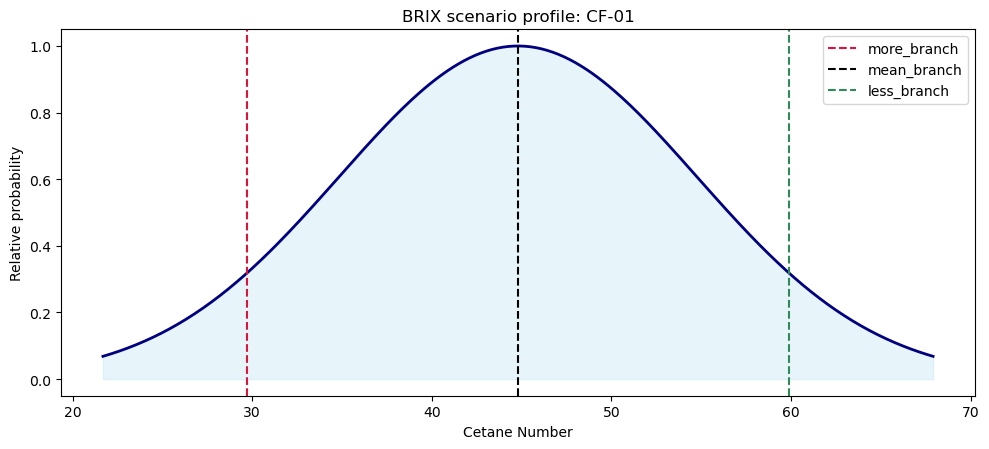

In [19]:
# Example curve for one sample with large BRIX effect span.
ex_idx = scenario_df['cn_branch_span'].idxmax()
row = scenario_df.loc[ex_idx]

x_vals = np.linspace(row['cn_more_branch'] - 8, row['cn_less_branch'] + 8, 300)
sigma = max(0.8, 0.33 * (row['cn_less_branch'] - row['cn_more_branch']))
pdf = np.exp(-0.5 * ((x_vals - row['cn_mean_branch']) / sigma) ** 2)
pdf = pdf / (pdf.max() + 1e-12)

plt.figure(figsize=(10, 4.6))
plt.plot(x_vals, pdf, color='navy', lw=2)
plt.fill_between(x_vals, pdf, alpha=0.2, color='skyblue')
plt.axvline(row['cn_more_branch'], linestyle='--', color='crimson', label='more_branch')
plt.axvline(row['cn_mean_branch'], linestyle='--', color='black', label='mean_branch')
plt.axvline(row['cn_less_branch'], linestyle='--', color='seagreen', label='less_branch')
plt.title(f"BRIX scenario profile: {row['mixture_name']}")
plt.xlabel('Cetane Number')
plt.ylabel('Relative probability')
plt.legend()
plt.tight_layout()
plt.show()